# TalentCLEF 2025 — Task B: Job-Skill Matching with Skill Type Classification

**Authors:** Hussain Mustansir, Mahrukh Yousuf, Afiya Sohail  
**Affiliation:** Habib University, Karachi, Pakistan  

---

**Goal:** Given a job title, retrieve a ranked list of relevant skills from the ESCO taxonomy and classify each as **core** (relevance=2) or **contextual** (relevance=1).

**Approach:**
1. **Bi-Encoder Retrieval** — Encode job titles and skills into a shared embedding space, rank by cosine similarity
2. **Cross-Encoder Reranking** — Rerank top-K candidates with a cross-encoder for better precision
3. **Skill Type Classification** — Classify each retrieved skill as core vs contextual

**Evaluation:** nDCG, MAP, MRR, P@K

---
# Section 1: Setup & Installation

In [2]:
# Install required libraries
!pip install -q sentence-transformers ranx pandas numpy scikit-learn matplotlib tqdm

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.4/285.4 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 5.6 MB/s eta 0:00:00


In [3]:
import os
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from collections import defaultdict

import torch
from torch.utils.data import DataLoader, Dataset

from sentence_transformers import (
    SentenceTransformer,
    InputExample,
    losses,
    evaluation
)
from sklearn.metrics import classification_report, f1_score
from ranx import Qrels, Run, evaluate

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


---
# Section 2: Download & Organize Dataset

**Steps to get the data:**
1. Download the TalentCLEF TaskB dataset from the official source
2. Upload it to your Google Drive OR directly to Colab
3. Update the `DATA_DIR` path below accordingly

**Expected folder structure:**
```
TaskB/
├── training/
│   ├── job2skill.tsv
│   ├── jobid2terms.json
│   └── skillid2terms.json
├── validation/
│   ├── queries
│   ├── corpus_elements
│   └── qrels.tsv
└── test/
```

In [4]:
# Mount Google Drive (if using Drive for data storage)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ============================================================
# SET YOUR DATA PATH HERE
# ============================================================
# Option A: If data is in Google Drive
DATA_DIR = '/content/drive/MyDrive/TalentCLEF/TaskB'

# Option B: If data is uploaded directly to Colab
# DATA_DIR = '/content/TaskB'

TRAIN_DIR = os.path.join(DATA_DIR, 'training')
VAL_DIR = os.path.join(DATA_DIR, 'validation')
TEST_DIR = os.path.join(DATA_DIR, 'test')

# Verify files exist
print("=== Training Files ===")
for f in os.listdir(TRAIN_DIR):
    print(f"  {f} ({os.path.getsize(os.path.join(TRAIN_DIR, f)) / 1024:.1f} KB)")

print("\n=== Validation Files ===")
for f in os.listdir(VAL_DIR):
    print(f"  {f} ({os.path.getsize(os.path.join(VAL_DIR, f)) / 1024:.1f} KB)")

=== Training Files ===
  jobid2terms.json (1516.7 KB)
  job2skill.tsv (17310.7 KB)
  skillid2terms.json (5300.2 KB)

=== Validation Files ===
  qrels.tsv (1793.2 KB)
  corpus_elements (2938.0 KB)
  queries (11.7 KB)


---
# Section 3: Load & Explore Data

## 3.1 Load Training Data

In [6]:
# Load job2skill.tsv — the core training file
job2skill = pd.read_csv(
    os.path.join(TRAIN_DIR, 'job2skill.tsv'),
    sep='\t',
    header=None,
    names=['job_id', 'skill_id', 'rel_type']
)
print(f"job2skill shape: {job2skill.shape}")
print(f"Columns: {list(job2skill.columns)}")
print(f"\nrel_type distribution:")
print(job2skill['rel_type'].value_counts())
print(f"\nUnique jobs: {job2skill['job_id'].nunique()}")
print(f"Unique skills: {job2skill['skill_id'].nunique()}")
job2skill.head()

job2skill shape: (114699, 3)
Columns: ['job_id', 'skill_id', 'rel_type']

rel_type distribution:
rel_type
essential    62480
optional     52219
Name: count, dtype: int64

Unique jobs: 3011
Unique skills: 13224


,job_id,skill_id,rel_type
0,http://data.europa.eu/esco/occupation/00030d09...,http://data.europa.eu/esco/skill/93a68dcb-3dc6...,essential
1,http://data.europa.eu/esco/occupation/00030d09...,http://data.europa.eu/esco/skill/05bc7677-5a64...,essential
2,http://data.europa.eu/esco/occupation/00030d09...,http://data.europa.eu/esco/skill/860be36a-d19b...,essential
3,http://data.europa.eu/esco/occupation/00030d09...,http://data.europa.eu/esco/skill/fed5b267-73fa...,essential
4,http://data.europa.eu/esco/occupation/00030d09...,http://data.europa.eu/esco/skill/f64fe2c2-d090...,essential


In [7]:
# Load jobid2terms.json — job title variants
with open(os.path.join(TRAIN_DIR, 'jobid2terms.json'), 'r') as f:
    jobid2terms = json.load(f)

print(f"Number of job IDs: {len(jobid2terms)}")
# Show one example
example_job_id = list(jobid2terms.keys())[0]
print(f"\nExample job ID: {example_job_id}")
print(f"Variants: {jobid2terms[example_job_id]}")

Number of job IDs: 3039

Example job ID: http://data.europa.eu/esco/occupation/00030d09-2b3a-4efd-87cc-c4ea39d27c34
Variants: ['technical director', 'technical and operations director', 'head of technical', 'director of technical arts', 'head of technical department', 'technical supervisor', 'technical manager']


In [8]:
# Load skillid2terms.json — skill name variants
with open(os.path.join(TRAIN_DIR, 'skillid2terms.json'), 'r') as f:
    skillid2terms = json.load(f)

print(f"Number of skill IDs: {len(skillid2terms)}")
# Show one example
example_skill_id = list(skillid2terms.keys())[0]
print(f"\nExample skill ID: {example_skill_id}")
print(f"Variants: {skillid2terms[example_skill_id]}")

Number of skill IDs: 13939

Example skill ID: http://data.europa.eu/esco/skill/0005c151-5b5a-4a66-8aac-60e734beb1ab
Variants: ['manage musical staff', 'manage staff of music', 'coordinate duties of musical staff', 'manage music staff', 'direct musical staff']


## 3.2 Load Validation Data

In [9]:
# Load validation queries
val_queries = pd.read_csv(
    os.path.join(VAL_DIR, 'queries'),
    sep='\t',
    header=0
)
print(f"Validation queries: {len(val_queries)}")
print(val_queries.head())

Validation queries: 304
          q_id                      jobtitle
0  dev_qb_jt_1  corporate governance analyst
1  dev_qb_jt_2    logistics business analyst
2  dev_qb_jt_3   operations planning analyst
3  dev_qb_jt_4      real estate data analyst
4  dev_qb_jt_5           security analyst ii


In [10]:
# Load validation corpus elements (the skill gazetteer)
val_corpus = pd.read_csv(
    os.path.join(VAL_DIR, 'corpus_elements'),
    sep='\t',
    header=0
)
print(f"Corpus skills: {len(val_corpus)}")
print(val_corpus.head())

Corpus skills: 9052
          c_id                                           esco_uri  \
0  dev_cb_sk_0  http://data.europa.eu/esco/skill/9bc3b9ae-50d8...   
1  dev_cb_sk_1  http://data.europa.eu/esco/skill/97965983-0da4...   
2  dev_cb_sk_2  http://data.europa.eu/esco/skill/2afb2b59-c9a3...   
3  dev_cb_sk_3  http://data.europa.eu/esco/skill/3e7516dc-0f7c...   
4  dev_cb_sk_4  http://data.europa.eu/esco/skill/a276b1ad-c0b7...   

                                       skill_aliases  
0  ['3D body scanning technologies', 'technologie...  
1  ['3D modelling', '3D designing', 'three-dimens...  
2                            ['3D printing process']  
3                                   ['3D texturing']  
4  ['5S methodology', '5S workplace organization ...  


In [12]:
# Load validation qrels (ground truth relevance judgments)
# Standard qrels format has NO header: q_id, iter, c_id, relevance
val_qrels = pd.read_csv(
    os.path.join(VAL_DIR, 'qrels.tsv'),
    sep='\t',
    header=None,
    names=['q_id', 'iter', 'c_id', 'relevance']
)
print(f"Qrels entries: {len(val_qrels)}")
print(f"\nRelevance distribution:")
print(val_qrels['relevance'].value_counts())
print(val_qrels.head())

Qrels entries: 56418

Relevance distribution:
relevance
1    40257
2    16161
Name: count, dtype: int64
          q_id  iter           c_id  relevance
0  dev_qb_jt_1     0   dev_cb_sk_64          1
1  dev_qb_jt_1     0  dev_cb_sk_197          1
2  dev_qb_jt_1     0  dev_cb_sk_202          2
3  dev_qb_jt_1     0  dev_cb_sk_204          1
4  dev_qb_jt_1     0  dev_cb_sk_261          1


## 3.3 Build Helper Mappings

In [13]:
# ============================================================
# BUILD TEXT REPRESENTATIONS
# ============================================================

# For training: create a text mapping for each job_id and skill_id
# Use the FIRST variant as the primary name
job_id_to_text = {jid: variants[0] for jid, variants in jobid2terms.items()}
skill_id_to_text = {sid: variants[0] for sid, variants in skillid2terms.items()}

# For validation: build query and corpus text lookups
val_query_text = dict(zip(val_queries['q_id'], val_queries['jobtitle']))

# Parse skill_aliases from string to list, then join as a single text
def parse_aliases(alias_str):
    """Parse the skill_aliases column which is a string repr of a list."""
    try:
        aliases = ast.literal_eval(alias_str)
        return aliases[0] if aliases else alias_str  # Use first alias as primary
    except:
        return alias_str

val_corpus['primary_skill'] = val_corpus['skill_aliases'].apply(parse_aliases)
val_corpus_text = dict(zip(val_corpus['c_id'], val_corpus['primary_skill']))

print(f"Training jobs with text: {len(job_id_to_text)}")
print(f"Training skills with text: {len(skill_id_to_text)}")
print(f"Validation queries: {len(val_query_text)}")
print(f"Validation corpus: {len(val_corpus_text)}")

# Show examples
print(f"\nExample query: {list(val_query_text.items())[0]}")
print(f"Example corpus skill: {list(val_corpus_text.items())[0]}")

Training jobs with text: 3039
Training skills with text: 13939
Validation queries: 304
Validation corpus: 9052

Example query: ('dev_qb_jt_1', 'corporate governance analyst')
Example corpus skill: ('dev_cb_sk_0', '3D body scanning technologies')


---
# Section 4: Prepare Training Pairs

We need to convert the training data into pairs that a sentence-transformer can learn from:
- **(job_title, skill_text, label)** where label reflects relevance
- Essential/True → label 1 (positive pair)
- Optional/False → label 0.5 (weakly positive — still relevant, just contextual)
- We also need **negative pairs** (skills NOT associated with a job) → label 0

In [14]:
# ============================================================
# CREATE TRAINING EXAMPLES FOR BI-ENCODER
# ============================================================

# Map rel_type to numeric scores
rel_map = {'essential': 1.0, 'optional': 0.5}

# Build positive pairs from training data
train_examples = []
skipped = 0

for _, row in tqdm(job2skill.iterrows(), total=len(job2skill), desc="Building pairs"):
    job_id = row['job_id']
    skill_id = row['skill_id']
    rel_type = row['rel_type']

    # Get text representations
    job_text = job_id_to_text.get(job_id)
    skill_text = skill_id_to_text.get(skill_id)

    if job_text is None or skill_text is None:
        skipped += 1
        continue

    label = rel_map.get(rel_type, 0.0)
    train_examples.append(InputExample(
        texts=[job_text, skill_text],
        label=label
    ))

print(f"Total training pairs: {len(train_examples)}")
print(f"Skipped (missing text): {skipped}")
print(f"\nSample pair:")
print(f"  Job: {train_examples[0].texts[0]}")
print(f"  Skill: {train_examples[0].texts[1]}")
print(f"  Label: {train_examples[0].label}")

Building pairs:   0%|          | 0/114699 [00:00<?, ?it/s]

Total training pairs: 114699
Skipped (missing text): 0

Sample pair:
  Job: technical director
  Skill: promote health and safety
  Label: 1.0


In [15]:
# ============================================================
# ADD HARD NEGATIVES
# ============================================================
# For each job, sample skills that are NOT associated with it

import random
random.seed(42)

# Build a set of positive skill_ids per job
job_positive_skills = defaultdict(set)
for _, row in job2skill.iterrows():
    job_positive_skills[row['job_id']].add(row['skill_id'])

all_skill_ids = list(skill_id_to_text.keys())
negative_examples = []

# Sample N negatives per job (N = number of positives for that job)
for job_id, pos_skills in tqdm(job_positive_skills.items(), desc="Sampling negatives"):
    job_text = job_id_to_text.get(job_id)
    if job_text is None:
        continue

    n_neg = min(len(pos_skills), 5)  # Cap at 5 negatives per job
    neg_candidates = [s for s in all_skill_ids if s not in pos_skills]
    neg_sample = random.sample(neg_candidates, min(n_neg, len(neg_candidates)))

    for skill_id in neg_sample:
        skill_text = skill_id_to_text.get(skill_id)
        if skill_text:
            negative_examples.append(InputExample(
                texts=[job_text, skill_text],
                label=0.0
            ))

print(f"Negative examples: {len(negative_examples)}")

# Combine all examples
all_train_examples = train_examples + negative_examples
random.shuffle(all_train_examples)
print(f"Total training examples: {len(all_train_examples)}")

Sampling negatives:   0%|          | 0/3011 [00:00<?, ?it/s]

Negative examples: 15055
Total training examples: 129754


---
# Section 5: Define Model & Hyperparameters

We use a **Bi-Encoder** architecture with `sentence-transformers`:
- Encodes job titles and skills independently
- Trained with **CosineSimilarityLoss** to push relevant pairs closer
- At inference, we encode all corpus skills once, then rank by cosine similarity to each query

In [17]:
# ============================================================
# HYPERPARAMETERS
# ============================================================
# MODEL_NAME = 'all-MiniLM-L6-v2'  # Good baseline, fast
MODEL_NAME = 'intfloat/e5-base-v2'  # Alternative: stronger retrieval model
# MODEL_NAME = 'jinaai/jina-embeddings-v2-base-en'  # Alternative
# MODEL_NAME = 'jjzha/jobbert-base-cased'
# MODEL_NAME = 'xlm-roberta-base'

BATCH_SIZE = 64
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1
MAX_SEQ_LENGTH = 128
TOP_K = 50  # How many skills to retrieve per job title

print(f"Model: {MODEL_NAME}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Top-K retrieval: {TOP_K}")

Model: intfloat/e5-base-v2
Batch size: 64
Epochs: 3
Learning rate: 2e-05
Top-K retrieval: 50


In [18]:
# ============================================================
# LOAD MODEL
# ============================================================
model = SentenceTransformer(MODEL_NAME, device=device)
model.max_seq_length = MAX_SEQ_LENGTH

print(f"Model loaded: {MODEL_NAME}")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")
print(f"Max sequence length: {model.max_seq_length}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Model loaded: intfloat/e5-base-v2
Embedding dimension: 768
Max sequence length: 128


---
# Section 6: Training Loop

In [19]:
# ============================================================
# PREPARE DATALOADER & LOSS
# ============================================================
train_dataloader = DataLoader(
    all_train_examples,
    shuffle=True,
    batch_size=BATCH_SIZE
)

train_loss = losses.CosineSimilarityLoss(model)

warmup_steps = int(len(train_dataloader) * NUM_EPOCHS * WARMUP_RATIO)
print(f"Total training steps: {len(train_dataloader) * NUM_EPOCHS}")
print(f"Warmup steps: {warmup_steps}")

Total training steps: 6084
Warmup steps: 608


In [20]:
# ============================================================
# TRAIN THE BI-ENCODER
# ============================================================
OUTPUT_DIR = '/content/drive/MyDrive/TalentCLEF/models/bi-encoder'
# OUTPUT_DIR = '/content/models/bi-encoder'  # If not using Drive

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=NUM_EPOCHS,
    warmup_steps=warmup_steps,
    optimizer_params={'lr': LEARNING_RATE},
    output_path=OUTPUT_DIR,
    show_progress_bar=True,
    use_amp=True  # Mixed precision for faster training on T4
)

print(f"\nModel saved to: {OUTPUT_DIR}")

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,0.092703
1000,0.069258
1500,0.063444
2000,0.060737
2500,0.053350
3000,0.051803
3500,0.052638
4000,0.051477
4500,0.046613
5000,0.046315


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to: /content/drive/MyDrive/TalentCLEF/models/bi-encoder


In [ ]:
# ============================================================
# LOAD TRAINED MODEL (if resuming later)
# ============================================================
# model = SentenceTransformer(OUTPUT_DIR, device=device)

---
# Section 7: Retrieval — Encode & Rank

Now we:
1. Encode all validation corpus skills (once)
2. Encode each validation query (job title)
3. Compute cosine similarity → rank skills per query
4. Take top-K skills for each query

In [21]:
# ============================================================
# ENCODE VALIDATION CORPUS (all skills)
# ============================================================
corpus_ids = list(val_corpus_text.keys())
corpus_texts = [val_corpus_text[cid] for cid in corpus_ids]

print(f"Encoding {len(corpus_texts)} corpus skills...")
corpus_embeddings = model.encode(
    corpus_texts,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True  # For cosine similarity via dot product
)
print(f"Corpus embeddings shape: {corpus_embeddings.shape}")

Encoding 9052 corpus skills...


Batches:   0%|          | 0/36 [00:00<?, ?it/s]

Corpus embeddings shape: (9052, 768)


In [22]:
# ============================================================
# ENCODE VALIDATION QUERIES & RETRIEVE TOP-K
# ============================================================
query_ids = list(val_query_text.keys())
query_texts = [val_query_text[qid] for qid in query_ids]

print(f"Encoding {len(query_texts)} queries...")
query_embeddings = model.encode(
    query_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

# Compute similarity scores (dot product = cosine sim when normalized)
similarity_matrix = query_embeddings @ corpus_embeddings.T
print(f"Similarity matrix shape: {similarity_matrix.shape}")

Encoding 304 queries...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Similarity matrix shape: (304, 9052)


In [23]:
# ============================================================
# BUILD RANKED RESULTS (Run)
# ============================================================
run_dict = {}

for i, qid in enumerate(query_ids):
    scores = similarity_matrix[i]
    # Get top-K indices
    top_k_indices = np.argsort(scores)[::-1][:TOP_K]

    run_dict[qid] = {}
    for idx in top_k_indices:
        cid = corpus_ids[idx]
        run_dict[qid][cid] = float(scores[idx])

print(f"Generated rankings for {len(run_dict)} queries")
print(f"Top-K per query: {TOP_K}")

# Show example
example_qid = query_ids[0]
print(f"\nExample query: {example_qid} = '{val_query_text[example_qid]}'")
print("Top 5 retrieved skills:")
for cid, score in sorted(run_dict[example_qid].items(), key=lambda x: -x[1])[:5]:
    print(f"  {score:.4f} | {val_corpus_text[cid]}")

Generated rankings for 304 queries
Top-K per query: 50

Example query: dev_qb_jt_1 = 'corporate governance analyst'
Top 5 retrieved skills:
  0.9356 | implement corporate governance
  0.9275 | corporate sustainability
  0.8931 | advise on corporate social responsibility 
  0.8727 | analyse internal factors of companies
  0.8694 | review development process of an organisation


---
# Section 8: Evaluation

Evaluate retrieval performance using standard IR metrics:
- **nDCG@K** — Normalized Discounted Cumulative Gain
- **MAP** — Mean Average Precision
- **MRR** — Mean Reciprocal Rank
- **P@K** — Precision at K

In [24]:
# ============================================================
# BUILD QRELS (ground truth) FOR RANX
# ============================================================
qrels_dict = {}

for _, row in val_qrels.iterrows():
    qid = row['q_id']
    cid = row['c_id']
    rel = int(row['relevance'])

    if qid not in qrels_dict:
        qrels_dict[qid] = {}
    qrels_dict[qid][cid] = rel

print(f"Qrels built for {len(qrels_dict)} queries")

Qrels built for 304 queries


In [25]:
# ============================================================
# EVALUATE WITH RANX
# ============================================================
qrels = Qrels(qrels_dict)
run = Run(run_dict)

# Compute metrics
metrics = evaluate(
    qrels,
    run,
    metrics=[
        'ndcg@5', 'ndcg@10', 'ndcg@20',
        'map@10', 'map@20',
        'mrr@10',
        'precision@1', 'precision@5', 'precision@10',
        'recall@10', 'recall@20', 'recall@50'
    ]
)

print("=" * 50)
print("RETRIEVAL EVALUATION RESULTS")
print("=" * 50)
for metric, score in metrics.items():
    print(f"  {metric:20s}: {score:.4f}")

/usr/local/lib/python3.12/dist-packages/ranx/metrics/ndcg.py:72: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  scores[i] = _ndcg(qrels[i], run[i], k, rel_lvl, jarvelin)


RETRIEVAL EVALUATION RESULTS
  ndcg@5              : 0.3408
  ndcg@10             : 0.3288
  ndcg@20             : 0.3048
  map@10              : 0.0138
  map@20              : 0.0226
  mrr@10              : 0.6076
  precision@1         : 0.4178
  precision@5         : 0.4020
  precision@10        : 0.3819
  recall@10           : 0.0221
  recall@20           : 0.0411
  recall@50           : 0.0869


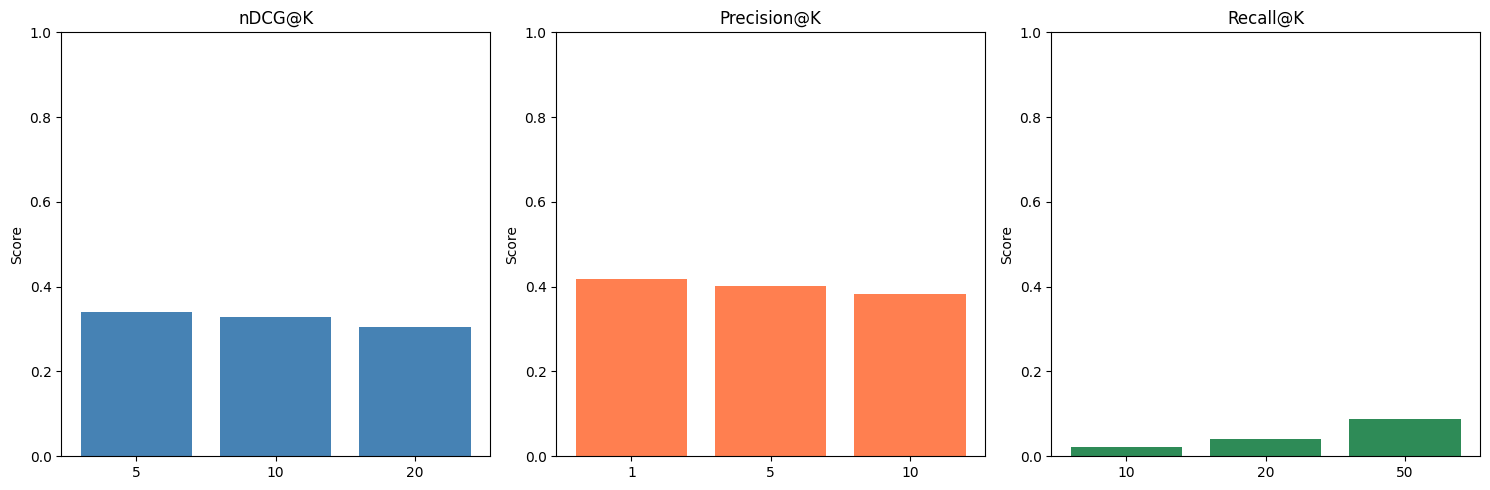

In [26]:
# ============================================================
# VISUALIZE RESULTS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# nDCG at different K
ndcg_ks = [5, 10, 20]
ndcg_vals = [metrics[f'ndcg@{k}'] for k in ndcg_ks]
axes[0].bar([str(k) for k in ndcg_ks], ndcg_vals, color='steelblue')
axes[0].set_title('nDCG@K')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)

# Precision at different K
p_ks = [1, 5, 10]
p_vals = [metrics[f'precision@{k}'] for k in p_ks]
axes[1].bar([str(k) for k in p_ks], p_vals, color='coral')
axes[1].set_title('Precision@K')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1)

# Recall at different K
r_ks = [10, 20, 50]
r_vals = [metrics[f'recall@{k}'] for k in r_ks]
axes[2].bar([str(k) for k in r_ks], r_vals, color='seagreen')
axes[2].set_title('Recall@K')
axes[2].set_ylabel('Score')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('retrieval_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Section 9: Skill Type Classification (Core vs Contextual)

After retrieval, we classify each retrieved skill as **core (2)** or **contextual (1)**.

Approach: Train a lightweight classifier on the (job_title, skill) pairs from training data,
using the similarity score + rel_type as features.

In [27]:
# ============================================================
# STRATEGY: USE SIMILARITY SCORE THRESHOLD FOR CLASSIFICATION
# ============================================================
# Simple but effective baseline:
# - Higher similarity → more likely to be CORE
# - Lower similarity → more likely to be CONTEXTUAL
# We'll find the optimal threshold on validation data

from sklearn.metrics import f1_score

# Collect (similarity_score, true_relevance) for all retrieved-and-relevant pairs
score_label_pairs = []

for qid in query_ids:
    if qid not in qrels_dict:
        continue
    for cid, score in run_dict[qid].items():
        if cid in qrels_dict[qid]:
            true_rel = qrels_dict[qid][cid]
            if true_rel > 0:  # Only for relevant skills
                score_label_pairs.append((score, true_rel))

scores_arr = np.array([p[0] for p in score_label_pairs])
labels_arr = np.array([p[1] for p in score_label_pairs])

print(f"Relevant retrieved pairs: {len(score_label_pairs)}")
print(f"Core (2): {(labels_arr == 2).sum()}, Contextual (1): {(labels_arr == 1).sum()}")
print(f"Score range: [{scores_arr.min():.4f}, {scores_arr.max():.4f}]")
print(f"Mean score for Core: {scores_arr[labels_arr == 2].mean():.4f}")
print(f"Mean score for Contextual: {scores_arr[labels_arr == 1].mean():.4f}")

Relevant retrieved pairs: 4597
Core (2): 2675, Contextual (1): 1922
Score range: [0.6730, 0.9792]
Mean score for Core: 0.8729
Mean score for Contextual: 0.8653


In [28]:
# ============================================================
# FIND OPTIMAL THRESHOLD
# ============================================================
best_f1 = 0
best_threshold = 0

for threshold in np.arange(scores_arr.min(), scores_arr.max(), 0.01):
    predicted = np.where(scores_arr >= threshold, 2, 1)
    f1 = f1_score(labels_arr, predicted, average='weighted')
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Best threshold: {best_threshold:.4f}")
print(f"Best weighted F1: {best_f1:.4f}")

# Apply threshold
predicted_labels = np.where(scores_arr >= best_threshold, 2, 1)
print(f"\nClassification Report:")
print(classification_report(
    labels_arr, predicted_labels,
    target_names=['Contextual (1)', 'Core (2)']
))

Best threshold: 0.8630
Best weighted F1: 0.5501

Classification Report:
                precision    recall  f1-score   support

Contextual (1)       0.46      0.47      0.47      1922
      Core (2)       0.61      0.61      0.61      2675

      accuracy                           0.55      4597
     macro avg       0.54      0.54      0.54      4597
  weighted avg       0.55      0.55      0.55      4597



---
# Section 10: Generate Submission File

Generate the output in qrels format for submission:
```
q_id    iter    c_id    relevance
```

In [29]:
# ============================================================
# GENERATE SUBMISSION
# ============================================================
def generate_submission(query_ids, run_dict, model, corpus_embeddings,
                       corpus_ids, threshold, output_path, top_k=50):
    """
    Generate submission file in qrels format.
    For each query, retrieve top-K skills and classify as core/contextual.
    """
    rows = []

    for qid in query_ids:
        ranked_skills = sorted(
            run_dict[qid].items(),
            key=lambda x: -x[1]
        )[:top_k]

        for cid, score in ranked_skills:
            # Classify: core (2) if score >= threshold, else contextual (1)
            relevance = 2 if score >= threshold else 1
            rows.append({
                'q_id': qid,
                'iter': 0,
                'c_id': cid,
                'relevance': relevance
            })

    submission_df = pd.DataFrame(rows)
    submission_df.to_csv(output_path, sep='\t', index=False)
    print(f"Submission saved: {output_path}")
    print(f"Total entries: {len(submission_df)}")
    print(f"Core predictions: {(submission_df['relevance'] == 2).sum()}")
    print(f"Contextual predictions: {(submission_df['relevance'] == 1).sum()}")
    return submission_df

# Generate for validation (to verify)
submission = generate_submission(
    query_ids, run_dict, model, corpus_embeddings,
    corpus_ids, best_threshold,
    output_path='submission_validation.tsv',
    top_k=TOP_K
)

Submission saved: submission_validation.tsv
Total entries: 15200
Core predictions: 7437
Contextual predictions: 7763


In [30]:
# ============================================================
# VIEW SUBMISSION RESULTS
# ============================================================
submission = pd.read_csv('submission_validation.tsv', sep='\t')

print(f"Shape: {submission.shape}")
print(f"\nRelevance distribution:")
print(submission['relevance'].value_counts())
print(f"\nFirst 20 rows:")
display(submission.head(20))

# Show results for a specific query
example_qid = submission['q_id'].unique()[0]
example_jobtitle = val_query_text[example_qid]
example_results = submission[submission['q_id'] == example_qid].copy()

# Add skill names for readability
example_results['skill_name'] = example_results['c_id'].map(val_corpus_text)
print(f"\n{'='*60}")
print(f"Query: {example_qid} = '{example_jobtitle}'")
print(f"{'='*60}")
print(f"\nCore skills (relevance=2):")
core = example_results[example_results['relevance'] == 2]
for _, row in core.iterrows():
    print(f"  - {row['skill_name']}")

print(f"\nContextual skills (relevance=1):")
ctx = example_results[example_results['relevance'] == 1]
for _, row in ctx.iterrows():
    print(f"  - {row['skill_name']}")

print(f"\nTotal: {len(core)} core, {len(ctx)} contextual")

Shape: (15200, 4)

Relevance distribution:
relevance
1    7763
2    7437
Name: count, dtype: int64

First 20 rows:


,q_id,iter,c_id,relevance
0,dev_qb_jt_1,0,dev_cb_sk_3625,2
1,dev_qb_jt_1,0,dev_cb_sk_1801,2
2,dev_qb_jt_1,0,dev_cb_sk_197,2
3,dev_qb_jt_1,0,dev_cb_sk_375,2
4,dev_qb_jt_1,0,dev_cb_sk_7305,2
5,dev_qb_jt_1,0,dev_cb_sk_2048,1
6,dev_qb_jt_1,0,dev_cb_sk_2490,1
7,dev_qb_jt_1,0,dev_cb_sk_7610,1
8,dev_qb_jt_1,0,dev_cb_sk_7776,1
9,dev_qb_jt_1,0,dev_cb_sk_361,1



Query: dev_qb_jt_1 = 'corporate governance analyst'

Core skills (relevance=2):
  - implement corporate governance
  - corporate sustainability
  - advise on corporate social responsibility 
  - analyse internal factors of companies
  - review development process of an organisation

Contextual skills (relevance=1):
  - define the corporate structure
  - disseminate general corporate information
  - shape corporate culture
  - strategic planning
  - analyse external factors of companies
  - forecast future levels of business
  - apply business acumen
  - decision support systems
  - report on overall management of a business
  - management consulting
  - monitor legislation developments
  - government policy implementation
  - imprint visionary aspirations into the business management
  - industrial research and development
  - evaluate company needs
  - apply strategic thinking
  - make data-driven decisions
  - carry out strategic research
  - consult with business clients
  - manage

---
# Section 11: Experiment with Second Model

Run the same pipeline with a different base model for comparison.

In [ ]:
# ============================================================
# MODEL 2: Try a different pre-trained model
# ============================================================
MODEL_NAME_2 = 'intfloat/e5-base-v2'
# NOTE: e5 models need "query: " and "passage: " prefixes

model2 = SentenceTransformer(MODEL_NAME_2, device=device)
model2.max_seq_length = MAX_SEQ_LENGTH

print(f"Model 2: {MODEL_NAME_2}")
print(f"Embedding dim: {model2.get_sentence_embedding_dimension()}")

In [ ]:
# For e5 models, add prefixes
# If using e5, uncomment the prefix lines below

# query_texts_e5 = [f"query: {t}" for t in query_texts]
# corpus_texts_e5 = [f"passage: {t}" for t in corpus_texts]

# For non-e5 models, use as-is
query_texts_m2 = query_texts
corpus_texts_m2 = corpus_texts

# Encode
print("Encoding corpus with Model 2...")
corpus_emb_2 = model2.encode(corpus_texts_m2, batch_size=256, show_progress_bar=True,
                              convert_to_numpy=True, normalize_embeddings=True)

print("Encoding queries with Model 2...")
query_emb_2 = model2.encode(query_texts_m2, batch_size=64, show_progress_bar=True,
                             convert_to_numpy=True, normalize_embeddings=True)

# Compute similarities
sim_matrix_2 = query_emb_2 @ corpus_emb_2.T

# Build run
run_dict_2 = {}
for i, qid in enumerate(query_ids):
    scores = sim_matrix_2[i]
    top_k_indices = np.argsort(scores)[::-1][:TOP_K]
    run_dict_2[qid] = {corpus_ids[idx]: float(scores[idx]) for idx in top_k_indices}

# Evaluate
run_2 = Run(run_dict_2)
metrics_2 = evaluate(
    qrels, run_2,
    metrics=['ndcg@5', 'ndcg@10', 'ndcg@20', 'map@10', 'map@20', 'mrr@10',
             'precision@1', 'precision@5', 'precision@10']
)

print("\n" + "=" * 50)
print(f"MODEL 2 RESULTS: {MODEL_NAME_2}")
print("=" * 50)
for metric, score in metrics_2.items():
    print(f"  {metric:20s}: {score:.4f}")

In [ ]:
# ============================================================
# COMPARE MODELS
# ============================================================
comparison_metrics = ['ndcg@5', 'ndcg@10', 'map@10', 'mrr@10', 'precision@5']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_metrics))
width = 0.35

m1_vals = [metrics[m] for m in comparison_metrics]
m2_vals = [metrics_2[m] for m in comparison_metrics]

bars1 = ax.bar(x - width/2, m1_vals, width, label=MODEL_NAME, color='steelblue')
bars2 = ax.bar(x + width/2, m2_vals, width, label=MODEL_NAME_2, color='coral')

ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison_metrics, rotation=15)
ax.legend()
ax.set_ylim(0, 1)

# Add value labels
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Section 12: Generate Test Predictions (when test set is released)

Uncomment and run this section when the test set is available.

In [ ]:
# # ============================================================
# # LOAD TEST DATA
# # ============================================================
# test_queries = pd.read_csv(
#     os.path.join(TEST_DIR, 'queries'),
#     sep='\t', header=0
# )
# test_corpus = pd.read_csv(
#     os.path.join(TEST_DIR, 'corpus_elements'),
#     sep='\t', header=0
# )
#
# # Build text mappings
# test_query_text = dict(zip(test_queries['q_id'], test_queries['jobtitle']))
# test_corpus['primary_skill'] = test_corpus['skill_aliases'].apply(parse_aliases)
# test_corpus_text = dict(zip(test_corpus['c_id'], test_corpus['primary_skill']))
#
# # Encode
# test_corpus_ids = list(test_corpus_text.keys())
# test_corpus_embs = model.encode(
#     [test_corpus_text[c] for c in test_corpus_ids],
#     batch_size=256, show_progress_bar=True,
#     convert_to_numpy=True, normalize_embeddings=True
# )
#
# test_query_ids = list(test_query_text.keys())
# test_query_embs = model.encode(
#     [test_query_text[q] for q in test_query_ids],
#     batch_size=64, show_progress_bar=True,
#     convert_to_numpy=True, normalize_embeddings=True
# )
#
# # Retrieve & classify
# test_sim = test_query_embs @ test_corpus_embs.T
# test_run = {}
# for i, qid in enumerate(test_query_ids):
#     scores = test_sim[i]
#     top_k = np.argsort(scores)[::-1][:TOP_K]
#     test_run[qid] = {test_corpus_ids[idx]: float(scores[idx]) for idx in top_k}
#
# # Generate submission
# test_submission = generate_submission(
#     test_query_ids, test_run, model, test_corpus_embs,
#     test_corpus_ids, best_threshold,
#     output_path='submission_test.tsv', top_k=TOP_K
# )

---
# Summary & Notes

| Step | Description |
|------|-------------|
| Data Loading | Loaded ESCO training pairs + validation IR data |
| Training Pairs | Created positive (essential/optional) + hard negative pairs |
| Bi-Encoder | Fine-tuned sentence-transformer with CosineSimilarityLoss |
| Retrieval | Encoded corpus, ranked by cosine similarity |
| Classification | Threshold-based core vs contextual classification |
| Evaluation | nDCG, MAP, MRR, P@K using ranx |
| Model Comparison | Compared multiple pre-trained bases |

**Potential improvements:**
- Cross-encoder reranking on top-K results
- Use ALL skill aliases (not just first) for richer corpus encoding
- Train a dedicated classifier (MLP/logistic regression) for core vs contextual
- Use training data rel_type distribution per job to learn type patterns
- Ensemble multiple models' scores